In [1]:
# keep a record of the heat blob dynamics 
# and output the final classification of each blob as human or residual heat for each frame at the end
# also, keep a record of the postures
# output the final classification of posture in each image seq
    # -1: unknown or unlabeled; 
    # 0: absence; 
    # 1: presence, unclassified; 
    # 2: standing; 
    # 3: sitting by bed; 
    # 4: sitting on bed; 
    # 5: lying w/o cover; 
    # 6: lying with cover
import sys
from pathlib import Path
sys.path.insert(0, "/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/src")

import yaml
import json   
from organizer_module.postprocessor import PostProcessor
from dataset.dataset import ThermalDataset
from heatsource_detection_module.extract import HeatSourceDetector
from posture_detection_module.CNN_model import SimpleIRA_CNN
from posture_detection_module.utils import remap_labels_simple, inverse_remap_labels_simple, label_to_text_simple, ThermalInvariantPreprocessor
from organizer_module.track_kalman import Tracker
from data_visualization_module.plot import DataVisualizer
import torch
import cv2
from tqdm import tqdm
import numpy as np

dv = DataVisualizer()
data_name = "case_study_hall1"



In [2]:
# run the entire pipeline on one data entry with visualizer
def test_inference(data_name=data_name, model_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth', tag = "", k = None, corr = None, start_idx = 0):
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    
    # 1. load the dataset ===============================================
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    print(f"dataset {data_name}; length:", len(dataset))


    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module
    if k is not None:
        tracker = Tracker(k_thresh = k, temp_decrease_thresh = corr)
    else:
        tracker = Tracker()
    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()

    import matplotlib.pyplot as plt
    from tqdm import tqdm
    

    # 3. loop through each fraome ========================================
    #   3.1. prepare the ground truth label list
    gt_result_lst = []
    waittime = 1
    visualization = True
    for idx in tqdm(range(start_idx, len(dataset), 1)):
        # gt
        label = dataset.annotations_expanded[idx]
        gt_result_lst.append(label)

        # data
        ira_highres = dataset.get_ira_highres(idx)
        # make pixels less than 17 deg be 17 deg
        ira_highres[ira_highres < 18] = 18

        # plt.imshow(ira_highres)
        # plt.show()

        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

        #   3.2. detect presence with kalman tracker
        tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
        postprocessor.get_blobs(tracker.blobs, idx)

        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        hasHuman = False
        for blob in tracker.blobs:
            if blob.is_residual == False: # if it is classified as human
                hasHuman = True

        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            postprocessor.get_posture(0, idx)

        # visualize the result for this frame
        if visualization:
            visualize_frame(ira_highres, tracker.blobs, posture_str, idx, 10)
    
    # 4. save the results to /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/{data_name}_{tag}.json', 'w') as f:
        json.dump({'results': postprocessor.posture_records, 'gt_result_lst': gt_result_lst}, f, indent=4)

    # draw the confusion matrix for posture classificatino result
    # confusion_matrix_draw(postprocessor.posture_records, gt_result_lst)


In [3]:
# visualization, 
posture_lst = []
exit_warning = 0
def visualize_frame(ira, blobs, posture_label, index, waittime = 1):
    global posture_lst, exit_warning
    # visualize the blobs and posture label on the ira_highres image, and save the image to disk
    # flip thermal map upside down
    ira = cv2.flip(ira, 0)

    thermal_prepared = dv._prepare_thermal_for_colormap(ira)
    ira_color = cv2.applyColorMap(thermal_prepared, cv2.COLORMAP_JET)
    # rescale the image to 5 times
    scale_factor = 10
    ira_color = cv2.resize(ira_color, (ira_color.shape[1] * scale_factor, ira_color.shape[0] * scale_factor), interpolation=cv2.INTER_NEAREST)

    corr = 0
    k = 0

    # exit warning
    if len(posture_lst) > 10:
        if "standing" not in posture_lst[:18] and "absence" not in posture_lst[:18] and posture_lst[18] == "standing" and posture_lst[19] == "standing":
            exit_warning += 60
    posture_lst.append(posture_label)
    if len(posture_lst) > 20:
        posture_lst.pop(0)
    

    # plot the blobs on the image, use green circle for human and yellow circle for residual heat
    for blob in blobs:
        if blob.mean_temp is None or blob.centroid is None:
            continue
        color = (0, 255, 0) if blob.is_residual == False else (0, 255, 255)
        # cv2.circle(ira_color, (int(blob.centroid[1]), int(blob.centroid[0])), 10, color, 2)
        # mark the blob id on the image
        x_min, y_min, x_max, y_max = blob.get_state()
        # cv2.putText(ira_color, f'ID: {blob.id_fixed}', (int(x_min*scale_factor), int(y_min*scale_factor)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        # cv2.putText(ira_color, f"{'residual' if blob.is_residual else 'human'}", (int(x_min*scale_factor), int((y_min)*scale_factor)), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
        cv2.putText(ira_color, f"{'residual' if blob.is_residual else 'user'}", (int(x_min*scale_factor), int(ira_color.shape[0]-(y_min)*scale_factor)), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
        # cv2.putText(ira_color, f'corr: {blob.corr:.4f}; k: {blob.k:.4f}', (int(x_min*scale_factor), int((y_min+15)*scale_factor)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        # draw bbox
        corr = blob.corr
        k = blob.k
        if blob.exit:
            exit_warning += 60
        x_min = int(x_min * scale_factor)
        y_min = int(y_min * scale_factor)
        x_max = int(x_max * scale_factor)
        y_max = int(y_max * scale_factor)
        # flip y values
        y_min = ira_color.shape[0] - y_min
        y_max = ira_color.shape[0] - y_max
        cv2.rectangle(ira_color, (x_min, y_min), (x_max, y_max), color, 2)

    exit_warning = min(exit_warning, 60)

    # cv2.putText(ira_color, f'Frame: {index}| Posture: {posture_label}|Corr: {corr:.3f}|K: {k:.3f}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    cv2.putText(ira_color, f'Frame: {index}| Posture: {posture_label}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    if exit_warning > 0:
        exit_warning -= 1
        cv2.putText(ira_color, f'User stood up!', (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 4)

    cv2.imshow('ira', ira_color)
    key = cv2.waitKey(waittime)
    if key == ord('q'):
        cv2.destroyAllWindows()
        sys.exit(0)


In [4]:
def vis_json_results(data_name = data_name, suffix = "nopostprocess_exp"):
    import matplotlib.pyplot as plt
    from organizer_module.postprocessor import PostProcessor
    import numpy as np

    # load from json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/{data_name}_{suffix}.json', 'r') as f:
        data = json.load(f)
        results = data['results']
        gt_result_lst = data['gt_result_lst']

    print("DEBUG: results len: ", len(results))
    print("DEBUG: gt_result_lst len: ", len(gt_result_lst))

    # Apply Markov smoothing to the results
    # pp = PostProcessor()
    # pp.posture_records = results.copy()
    # # pp._markov_smoothing()
    # smoothed_results = pp.posture_records

    smoothed_results = results.copy()

    def compute_accuracy_presence(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g==0 and p == 0:
                correct += 1
            elif g in [1, 2, 3, 4, 5, 6]:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            total += 1
        return correct / total

    def compute_accuracy(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g == 1:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            elif p == g:
                    correct += 1
            total += 1
        return correct / total
    
    def compute_recall(pred, gt):
        # compute recall for each class
        recall_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            tp = sum([1 if p == cls and g == cls else 0 for p, g in zip(pred, gt)])
            fn = sum([1 if p != cls and g == cls else 0 for p, g in zip(pred, gt)])
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            recall_dict[cls] = recall
        return recall_dict
    
    def compute_precision(pred, gt):
        # compute precision for each class
        precision_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            tp = sum([1 if p == cls and g == cls else 0 for p, g in zip(pred, gt)])
            fp = sum([1 if p == cls and g != cls else 0 for p, g in zip(pred, gt)])
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            precision_dict[cls] = precision
        return precision_dict
    
    def compute_f1(pred, gt):
        recall_dict = compute_recall(pred, gt)
        precision_dict = compute_precision(pred, gt)
        f1_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            precision = precision_dict[cls]
            recall = recall_dict[cls]
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            f1_dict[cls] = f1
        return f1_dict

    accuracy_before = compute_accuracy(results, gt_result_lst)
    recall_before = compute_recall(results, gt_result_lst)
    precision_before = compute_precision(results, gt_result_lst)
    f1_before = compute_f1(results, gt_result_lst)
    # accuracy_after = compute_accuracy(smoothed_results, gt_result_lst)
    print("accuracy of presence: ", compute_accuracy_presence(results, gt_result_lst))
    print("accuracy of all poses: ", accuracy_before)
    
    print("recall of all poses: ", recall_before)

    plt.plot(smoothed_results, alpha = 0.5)
    # plt.plot(results, alpha = 0.5)
    plt.plot(gt_result_lst, alpha = 0.5)
    plt.show()
    # print(f"Accuracy before smoothing: {accuracy_before:.4f}")
    # print(f"Accuracy after smoothing: {accuracy_after:.4f}")

    # count the accuracy
    # when gt_results_lst is -1, we regard it as 0
    # when gt_results_lst is 1, it can match all the presence labels (2, 3, 4, 5, 6)
    # compute the accuracy
    correct = 0
    total = 0
    for i in range(len(gt_result_lst)):
        gt = gt_result_lst[i]
        pred = results[i]
        if gt == -1:
            gt = 0
        if gt == 1:
            if pred in [2, 3, 4, 5, 6]:
                correct += 1
        else:
            if pred == gt:
                correct += 1
        total += 1
    accuracy = correct / total
    print(f"Posture accuracy: {accuracy:.4f}")

    # results = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 2]
    # exit prediction
    for i in range(10,len(results)-10):
        # if last 10 frames only have values within [3, 4, 5, 6]
        no2inPrev = True
        for idx in results[i-10:i]:
            if idx == 2:
                # print("found 2")
                no2inPrev = False
                break 
        
        if results[i] == 2 and no2inPrev:
            print(f"Exit predicted at frame {i} Pred: {results[i-1]} -> {results[i]})")
            
        # if gt_result_lst[i-1] in [0, 1] and gt_result_lst[i] in [2, 3, 4, 5, 6]:
        #     print(f"Entry predicted at frame {i} (GT: {gt_result_lst[i-1]} -> {gt_result_lst[i]}, Pred: {results[i-1]} -> {results[i]})")

    # plot confusion matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    # presence classification confusion matrix
    y_true = [1 if r in [2, 3, 4, 5, 6] else 0 for r in gt_result_lst]
    y_pred = [1 if r in [2, 3, 4, 5, 6] else 0 for r in results]
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix for Presence Classification:", cm)

    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Human'])
    # disp.plot(cmap=plt.cm.Blues)
    # plt.title("Confusion Matrix for Presence Classification (Binary)")
    # plt.show()

    # plot posture classification confusion matrix
    # remove ambiguous labels in gt_result_lst and results
    y_true = [r for r in gt_result_lst if r != -1 and r != 1]
    y_pred = [results[i] for i in range(len(results)) if gt_result_lst[i] != -1 and gt_result_lst[i] != 1]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 2, 3, 4, 5, 6])
    print("Confusion Matrix for Posture Classification (Detailed):", cm)

    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Standing', 'Sitting by Bed', 'Sitting on Bed', 'Lying w/o Cover', 'Lying with Cover'])
    # disp.plot(cmap=plt.cm.Blues)
    # # rotate x label by 45 degree
    # plt.xticks(rotation=45)
    # plt.title("Confusion Matrix for Posture Classification (Detailed)")
    # plt.show()
def vis_results(data_name = "office0_4", tag = ""):
    # visualize the results in /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_nopostprocess_exp.json
    # data_name = "home01"
    vis_json_results(data_name, tag)


dataset office1_0; length: 6186


 88%|████████▊ | 5434/6186 [01:53<00:16, 45.97it/s]

Human left the bed! Residual heat detected. Frame index:  5426


100%|██████████| 6186/6186 [02:07<00:00, 48.67it/s]


DEBUG: results len:  6186
DEBUG: gt_result_lst len:  6186
accuracy of presence:  0.9954977488744372
accuracy of all poses:  0.9953309988327497
recall of all poses:  {0: 0.9873817034700315, 2: 1.0, 3: 0.9983221476510067, 4: 1.0, 5: 1.0, 6: 1.0}


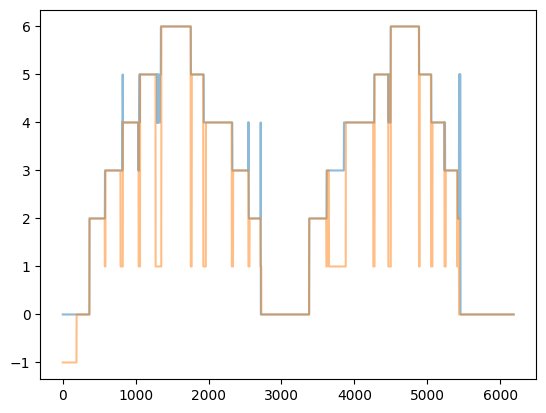

Posture accuracy: 0.9955
Exit predicted at frame 366 Pred: 0 -> 2)
Exit predicted at frame 2552 Pred: 3 -> 2)
Exit predicted at frame 3380 Pred: 0 -> 2)
Exit predicted at frame 5419 Pred: 3 -> 2)
Confusion Matrix for Presence Classification: [[1761  610]
 [   0 3815]]
Confusion Matrix for Posture Classification (Detailed): [[1565    3    0    0   17    0]
 [   0  603    0    0    0    0]
 [   0    0  595    1    0    0]
 [   0    0    0 1113    0    0]
 [   0    0    0    0  714    0]
 [   0    0    0    0    0  789]]


In [6]:
# test_results()
# test_postprocessor()
if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    # env = "office0_sf_0"
    env = "office1_0"
    model = "posture_cnn_cross_user_user5"
    tag = "cross_user"
    # tag = "nopostprocess_exp"
    k = 0.005
    corr = -0.75
    test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights_final/{model}_0417.pth', tag = 'cross_user', k = k, corr = corr, start_idx=0)
    vis_results(env, tag)
    # pipeline_gridsearch()
    # test_users_inenv()
    # test_users_crossenv()
    # saved here: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/office0_sf_0_cross_user.json